In [14]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [15]:
# Load dataset
df = pd.read_csv("../data/aerofit_treadmill.csv")
# Preview
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [16]:
# Shape
df.shape

(180, 9)

In [17]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [18]:
# Statistical summary
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [19]:
# Check missing values
df.isnull().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

In [20]:
# Convert categorical columns
cat_cols = ['Product', 'Gender', 'MaritalStatus']

for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


In [21]:
df.nunique()

Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
dtype: int64

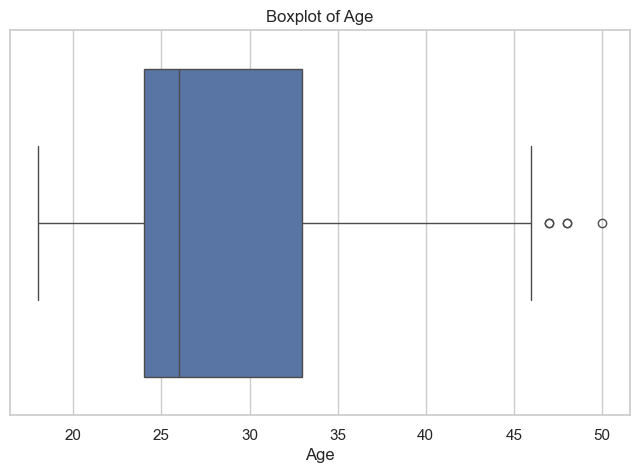

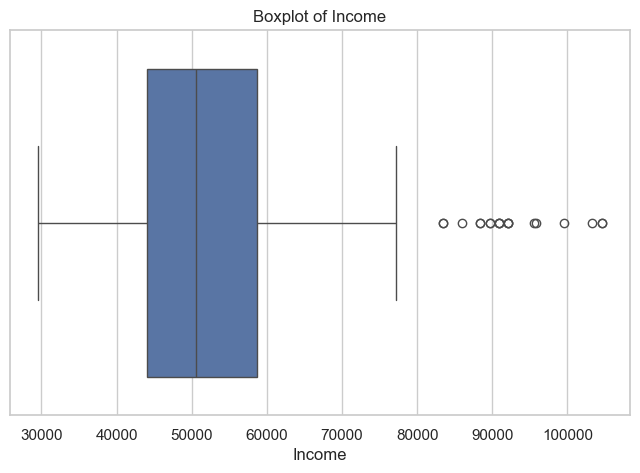

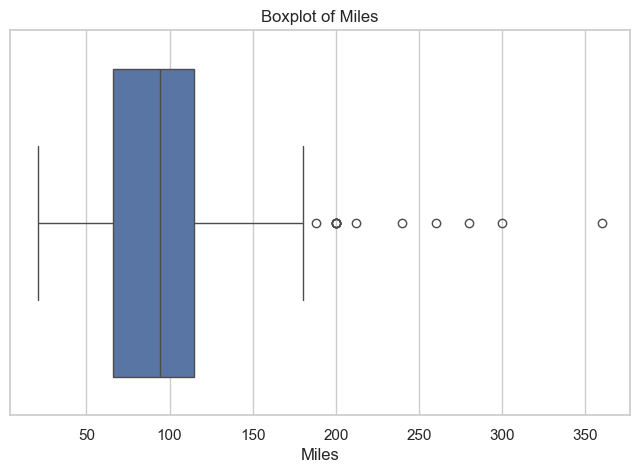

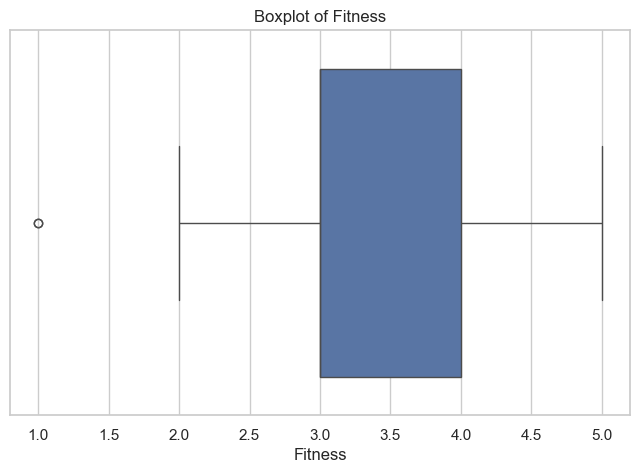

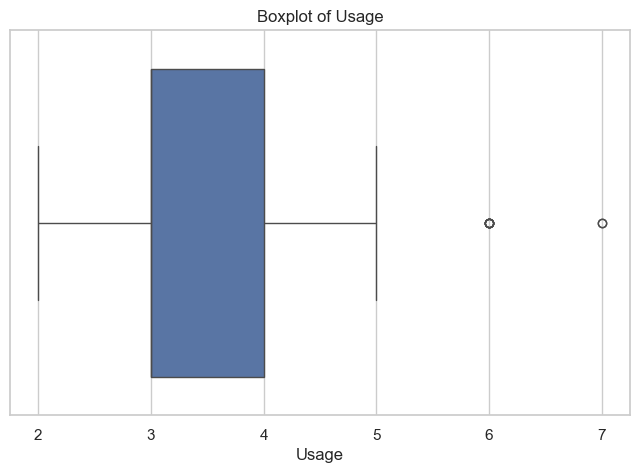

In [22]:
# Boxplots
num_cols = ['Age', 'Income', 'Miles', 'Fitness', 'Usage']

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

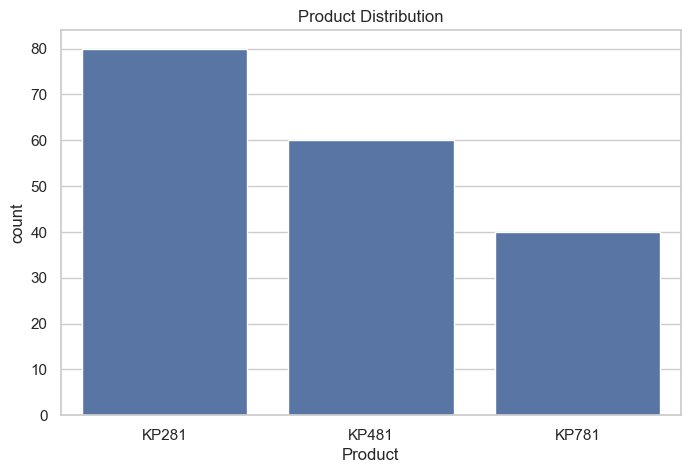

In [23]:
sns.countplot(x='Product', data=df)
plt.title("Product Distribution")
plt.show()

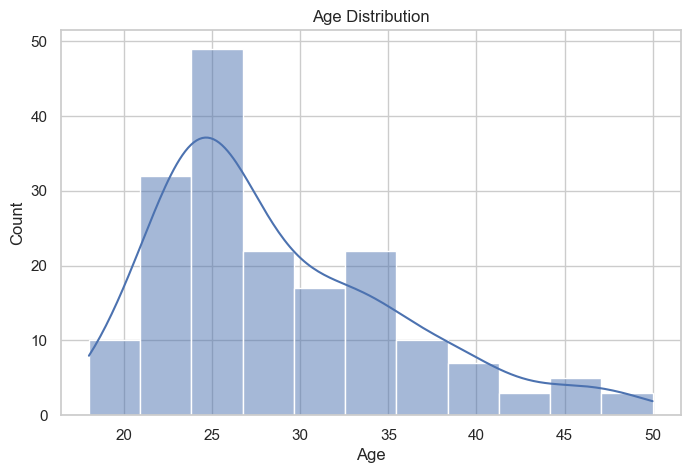

In [24]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

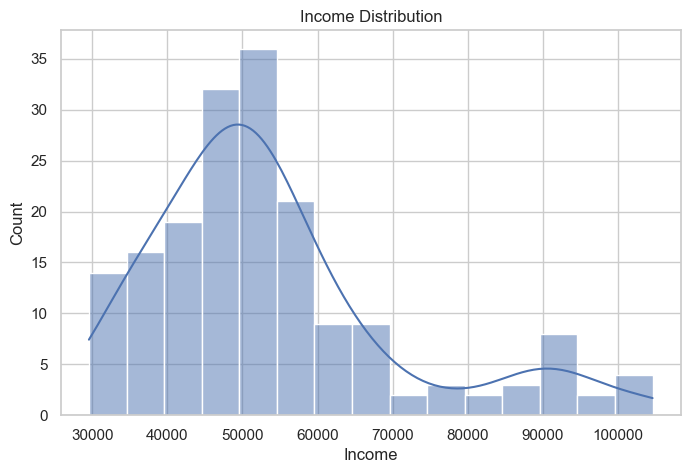

In [25]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

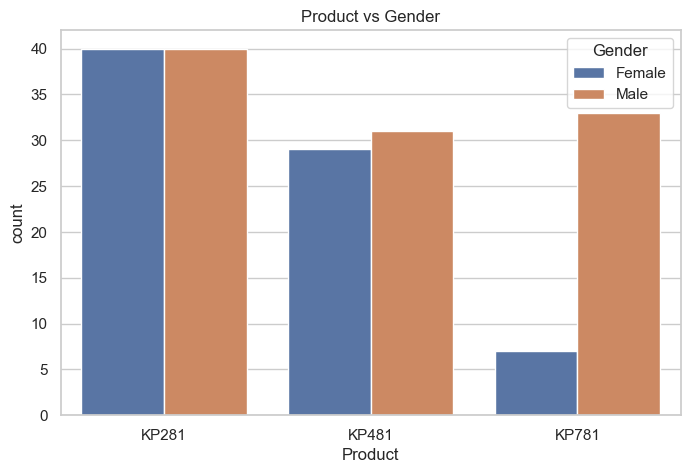

In [26]:
sns.countplot(x='Product', hue='Gender', data=df)
plt.title("Product vs Gender")
plt.show()

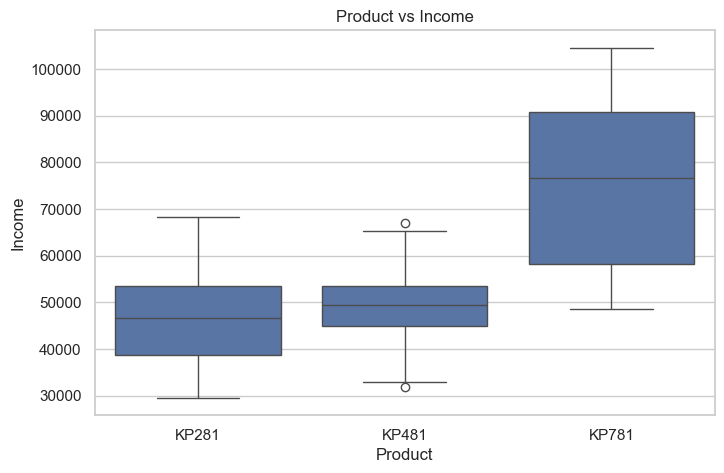

In [27]:
sns.boxplot(x='Product', y='Income', data=df)
plt.title("Product vs Income")
plt.show()

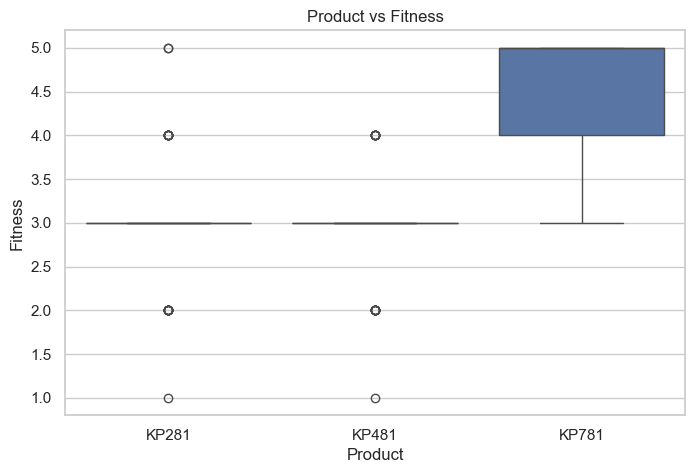

In [28]:
sns.boxplot(x='Product', y='Fitness', data=df)
plt.title("Product vs Fitness")
plt.show()

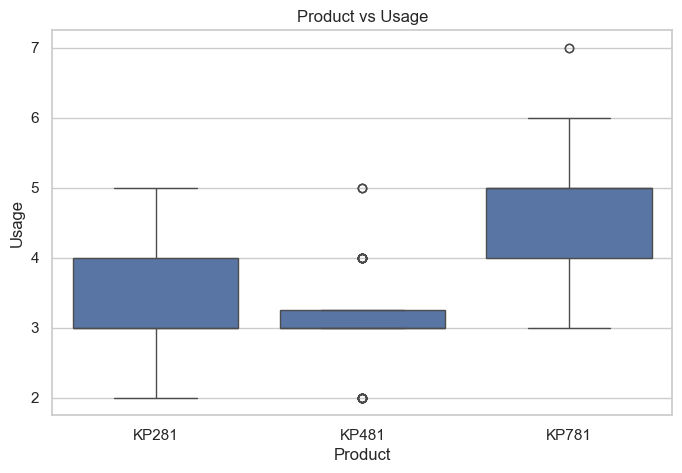

In [29]:
sns.boxplot(x='Product', y='Usage', data=df)
plt.title("Product vs Usage")
plt.show()

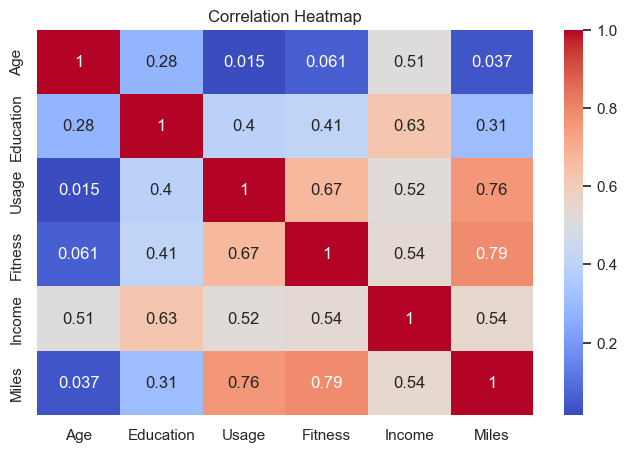

In [30]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [31]:
# Product vs Gender
pd.crosstab(df['Product'], df['Gender'], margins=True)



Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


In [32]:
# Product vs Marital Status
pd.crosstab(df['Product'], df['MaritalStatus'], margins=True)

MaritalStatus,Partnered,Single,All
Product,,,
KP281,48,32,80
KP481,36,24,60
KP781,23,17,40
All,107,73,180


In [33]:
# Product probability
product_prob = df['Product'].value_counts(normalize=True)
product_prob

Product
KP281    0.444444
KP481    0.333333
KP781    0.222222
Name: proportion, dtype: float64

In [34]:
male_total = len(df[df['Gender'] == 'Male'])
male_kp781 = len(df[(df['Gender'] == 'Male') & (df['Product'] == 'KP781')])

prob = male_kp781 / male_total
print("P(KP781 | Male) =", prob)

P(KP781 | Male) = 0.3173076923076923


In [35]:
ct = pd.crosstab(df['Gender'], df['Product'], normalize='index')
ct

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


In [36]:
# Group by product
profile = df.groupby('Product').mean(numeric_only=True)
profile

C:\Users\Ritu Raj Kashyap\AppData\Local\Temp\ipykernel_15572\2044048430.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile = df.groupby('Product').mean(numeric_only=True)


,Age,Education,Usage,Fitness,Income,Miles
Product,,,,,,
KP281,28.55,15.037500,3.087500,2.9625,46418.025,82.787500
KP481,28.90,15.116667,3.066667,2.9000,48973.650,87.933333
KP781,29.10,17.325000,4.775000,4.6250,75441.575,166.900000


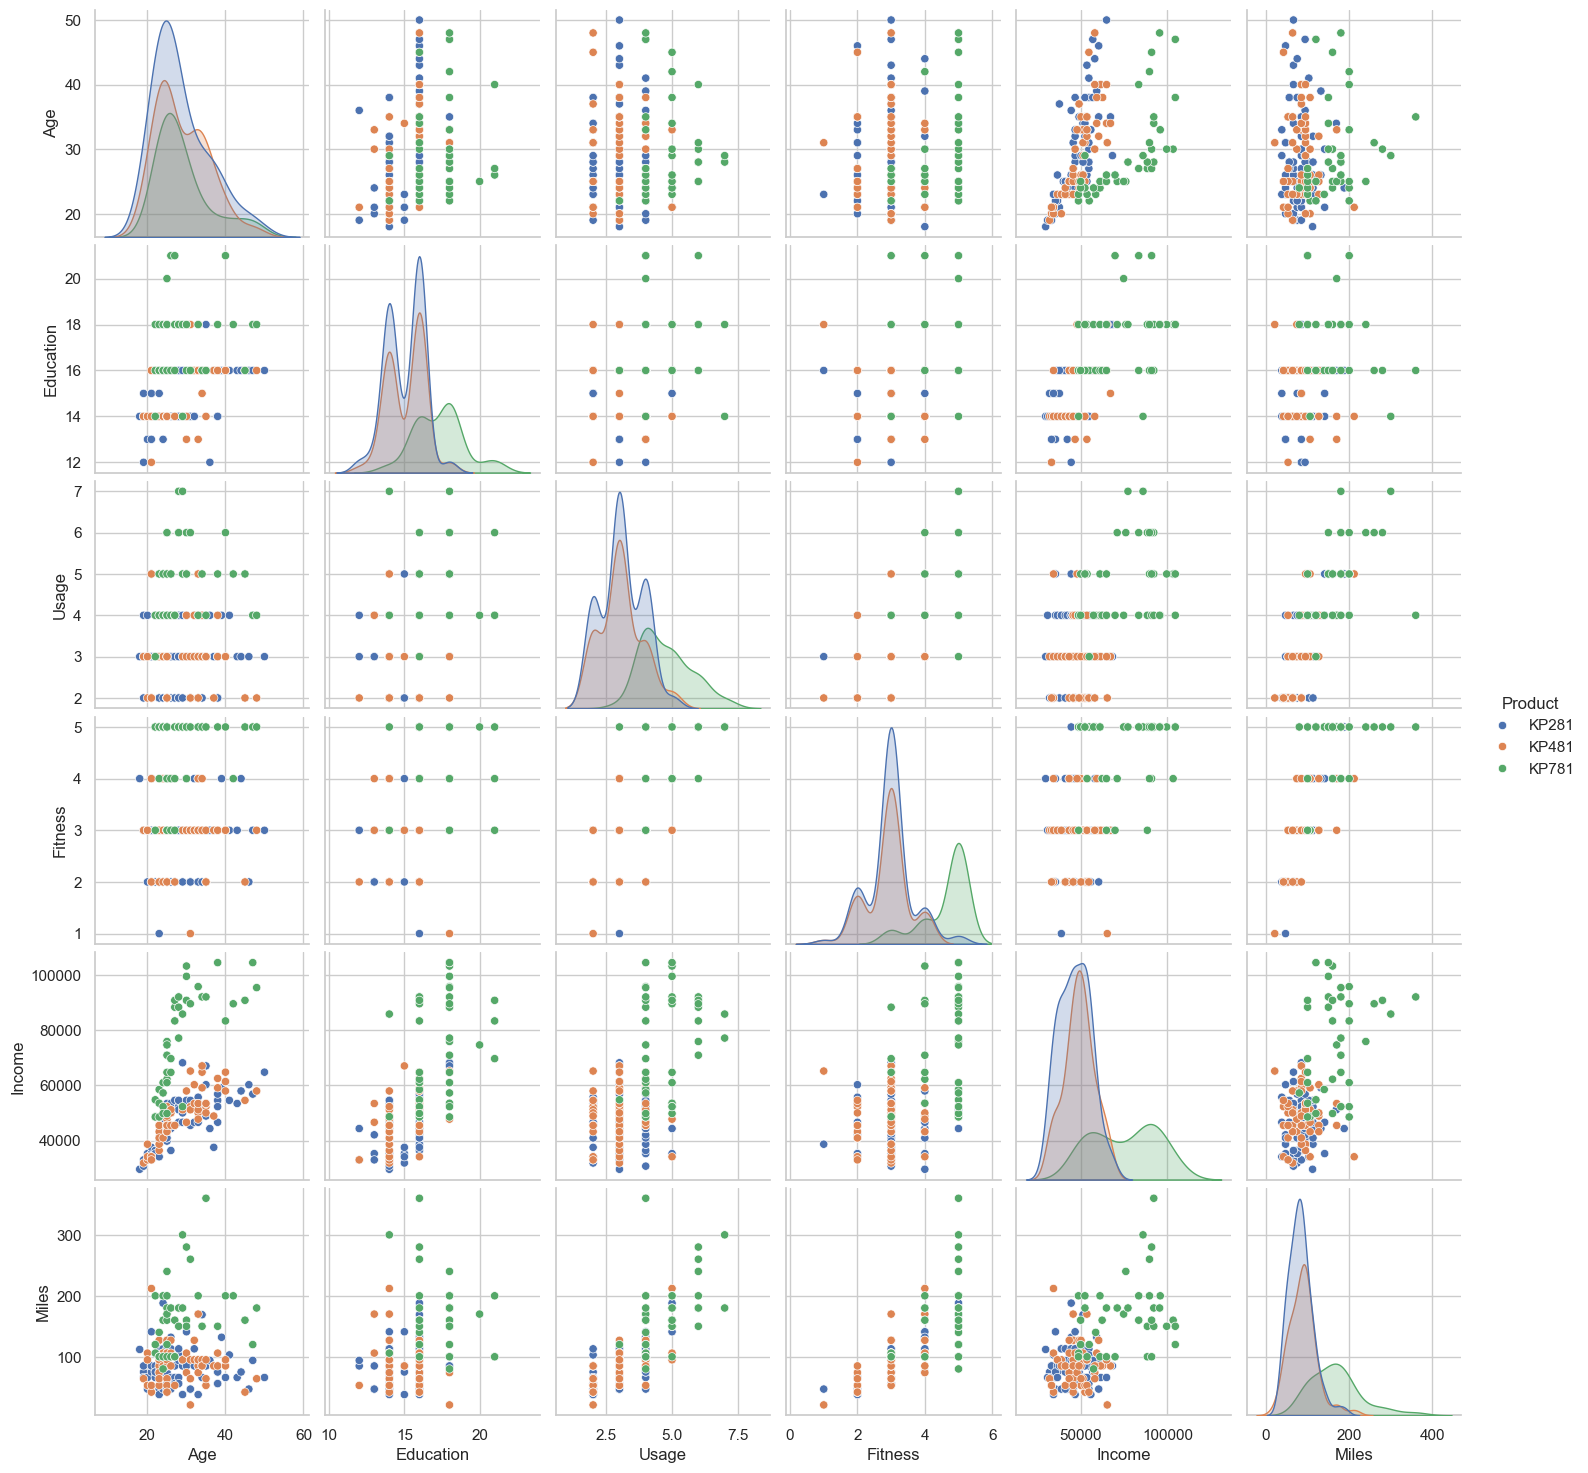

In [37]:
sns.pairplot(df, hue='Product')
plt.show()

- KP281 is the most purchased treadmill (entry-level)
- KP781 buyers have highest income and fitness levels
- Strong correlation between fitness, usage, and miles
- Male customers are more likely to buy KP781
- Income is the strongest predictor of product purchase

1. Target KP281 for beginners and budget users
2. Promote KP781 to high-income fitness enthusiasts
3. Introduce EMI options to upsell KP281 users
4. Build personalized recommendation system
5. Focus marketing based on fitness level and usage

**Now Using Ml,Predict which treadmill a customer will buy**

In [38]:
# Encoding categorical variables
df_encoded = df.copy()

df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})
df_encoded['MaritalStatus'] = df_encoded['MaritalStatus'].map({'Single': 0, 'Partnered': 1})

# Target encoding
df_encoded['Product'] = df_encoded['Product'].map({'KP281': 0, 'KP481': 1, 'KP781': 2})

# Features & Target
X = df_encoded.drop('Product', axis=1)
y = df_encoded['Product']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6388888888888888
              precision    recall  f1-score   support

           0       0.65      0.72      0.68        18
           1       0.25      0.22      0.24         9
           2       1.00      0.89      0.94         9

    accuracy                           0.64        36
   macro avg       0.63      0.61      0.62        36
weighted avg       0.64      0.64      0.64        36



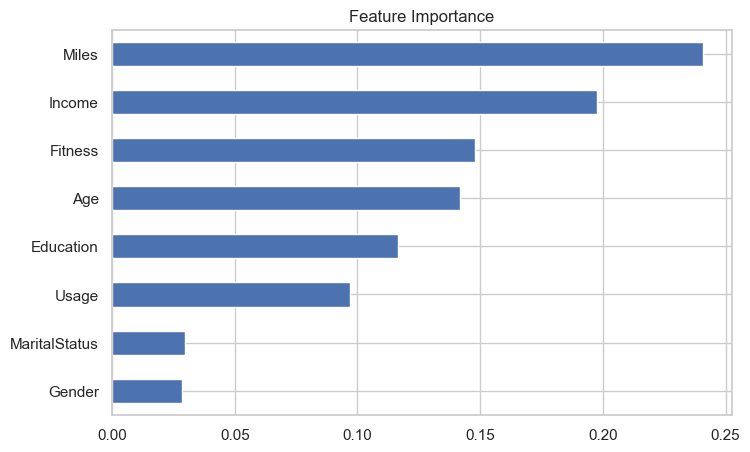

In [41]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

**Customer Segmentation (K-Means Clustering)**-Automatically group customers into segments

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[['Age', 'Income', 'Fitness', 'Miles', 'Usage']]

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

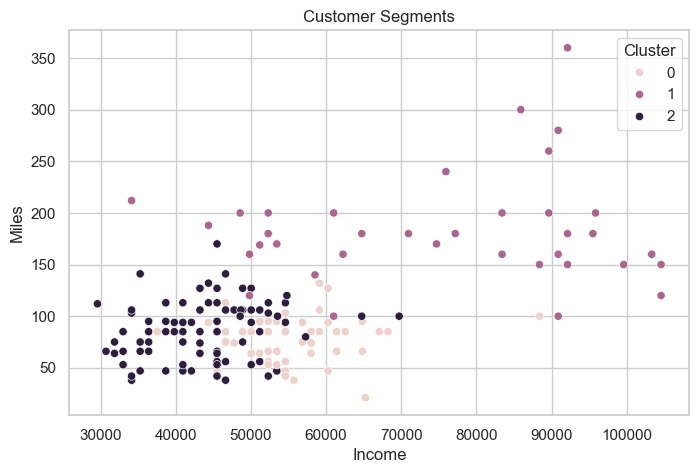

In [43]:
sns.scatterplot(x='Income', y='Miles', hue='Cluster', data=df)
plt.title("Customer Segments")
plt.show()

Cluster	Type
0	Low income, beginners
1	Mid-level users
2	High income, athletes

**Recommendation System**-Suggest treadmill based on user profile

In [44]:
def recommend_treadmill(income, fitness, usage):
    if income > 80000 and fitness >= 4:
        return "KP781 (Advanced)"
    elif income > 50000:
        return "KP481 (Mid-Level)"
    else:
        return "KP281 (Entry-Level)"

In [45]:
recommend_treadmill(90000, 5, 5)

'KP781 (Advanced)'

In [46]:
recommend_treadmill(6000, 2, 4)

'KP281 (Entry-Level)'